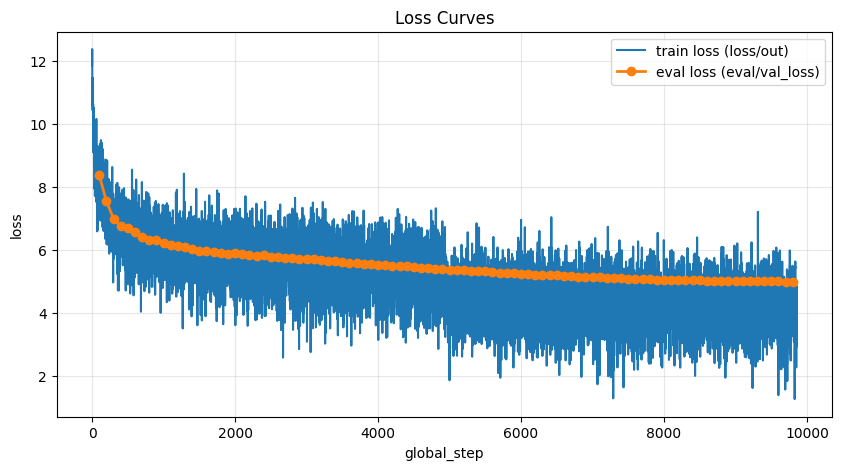

In [ ]:
import json
from pathlib import Path
from typing import Any, Dict, List, Tuple

import matplotlib.pyplot as plt


# ---- set this in Colab ----
METRICS_PATH = "metrics.jsonl"   # or "/content/metrics.jsonl"


def read_metrics(path: str) -> List[Dict[str, Any]]:
    """
    Reads:
      - JSONL: one JSON object per line
      - OR JSON: a list of JSON objects (array)
    Returns a list[dict].
    """
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"File not found: {p}")

    text = p.read_text(encoding="utf-8").strip()
    if not text:
        return []

    # Try JSON (array/object) first
    try:
        obj = json.loads(text)
        if isinstance(obj, list):
            return obj
        if isinstance(obj, dict):
            # single dict -> wrap
            return [obj]
    except json.JSONDecodeError:
        pass

    # Fallback: JSONL
    rows: List[Dict[str, Any]] = []
    with p.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as e:
                raise ValueError(f"Failed to parse JSON on line {i}: {e}\nLine: {line[:200]}") from e
    return rows


def extract_series(rows: List[Dict[str, Any]]) -> Tuple[List[int], List[float], List[int], List[float]]:
    train_steps, train_loss = [], []
    eval_steps, eval_loss = [], []

    for r in rows:
        step = r.get("global_step", None)
        if step is None:
            continue
        step = int(step)

        if "loss/out" in r:
            train_steps.append(step)
            train_loss.append(float(r["loss/out"]))

        if "eval/val_loss" in r:
            eval_steps.append(step)
            eval_loss.append(float(r["eval/val_loss"]))

    # Sort by step (in case out of order)
    train_sorted = sorted(zip(train_steps, train_loss), key=lambda x: x[0])
    eval_sorted  = sorted(zip(eval_steps,  eval_loss),  key=lambda x: x[0])

    train_steps, train_loss = [s for s, _ in train_sorted], [v for _, v in train_sorted]
    eval_steps, eval_loss   = [s for s, _ in eval_sorted],  [v for _, v in eval_sorted]

    return train_steps, train_loss, eval_steps, eval_loss


# ---- run ----
rows = read_metrics(METRICS_PATH)
train_steps, train_loss, eval_steps, eval_loss = extract_series(rows)

if not train_steps and not eval_steps:
    raise RuntimeError("No train/eval loss found. Expected keys: 'loss/out' and/or 'eval/val_loss'.")

plt.figure(figsize=(10, 5))
if train_steps:
    plt.plot(train_steps, train_loss, label="train loss (loss/out)")
if eval_steps:
    plt.plot(eval_steps, eval_loss, marker="o", linewidth=2, label="eval loss (eval/val_loss)")

plt.xlabel("global_step")
plt.ylabel("loss")
plt.title("Loss Curves")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [ ]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Path to your metrics file(s).
# Common patterns:
#   metrics.jsonl
#   logs/metrics.jsonl
#   logs/*.jsonl
LOG_GLOB = "metrics.jsonl"   # <-- change this to your path/glob

# Keys in your JSON lines
STEP_KEY = "global_step"
LOSS_KEY = "loss/out"

# Optional: smooth the loss curve (moving average window size in points)
SMOOTH_WINDOW = 50   # set to 0 to disable smoothing

# Optional: keep only every N points to speed up plotting for very large logs
DOWNSAMPLE_EVERY = 1  # e.g., 10 means keep every 10th record


In [ ]:
def read_jsonl_files(glob_pattern: str) -> pd.DataFrame:
    paths = sorted(Path(".").glob(glob_pattern))
    if not paths:
        raise FileNotFoundError(
            f"No files matched {glob_pattern!r}. "
            "Update LOG_GLOB to point to your metrics JSONL."
        )

    rows = []
    bad_lines = 0

    for p in paths:
        with p.open("r", encoding="utf-8") as f:
            for line_no, line in enumerate(f, start=1):
                line = line.strip()
                if not line:
                    continue
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError:
                    bad_lines += 1

    df = pd.DataFrame(rows)
    print(f"Loaded {len(df):,} records from {len(paths)} file(s).")
    if bad_lines:
        print(f"Warning: skipped {bad_lines:,} malformed line(s).")
    return df

df_raw = read_jsonl_files(LOG_GLOB)

# Show a quick peek
df_raw.head()


Loaded 9,953 records from 1 file(s).


,global_step,acc_step,speed/wps,speed/FLOPS,speed/curr_iter_time,speed/data_load_time,optim/grad_norm,optim/lr,optim/total_tokens,memory/max_active_gib,...,memory/max_reserved_pct,memory/num_alloc_retries,memory/num_ooms,memory/power_draw,loss/out,created_at,eval/val_loss,eval/val_perplexity,eval/val_tokens,eval/val_steps
0,1,0.0,13.471417,6.613273e+10,1.6772,0.2630,79.425209,0.000000e+00,464.0,9.865506,...,27.240837,0.0,0.0,124987.0,11.844686,2026-01-21T12:17:41.219668+00:00,NaN,NaN,NaN,NaN
1,2,0.0,205.579881,9.992132e+11,0.8326,0.0004,78.258476,5.000000e-07,832.0,12.717075,...,36.460407,0.0,0.0,127460.0,12.362827,2026-01-21T12:17:43.127534+00:00,NaN,NaN,NaN,NaN
2,3,0.0,301.125040,1.480451e+12,0.8036,0.0006,78.057983,1.000000e-06,1536.0,12.996787,...,36.482400,0.0,0.0,125572.0,11.425649,2026-01-21T12:17:44.642483+00:00,NaN,NaN,NaN,NaN
3,4,0.0,312.289602,1.530723e+12,0.7971,0.0003,78.097588,1.500000e-06,1600.0,12.791774,...,36.482400,0.0,0.0,125315.0,11.246838,2026-01-21T12:17:46.128893+00:00,NaN,NaN,NaN,NaN
4,5,0.0,358.038725,1.749194e+12,0.7817,0.0004,70.138405,2.000000e-06,3600.0,13.070024,...,36.482400,0.0,0.0,122503.0,11.169036,2026-01-21T12:17:47.604185+00:00,NaN,NaN,NaN,NaN


In [ ]:
def extract_step_loss(df: pd.DataFrame, step_key: str, loss_key: str) -> pd.DataFrame:
    if step_key not in df.columns:
        raise KeyError(f"Missing {step_key!r} in columns: {list(df.columns)}")
    if loss_key not in df.columns:
        raise KeyError(f"Missing {loss_key!r} in columns: {list(df.columns)}")

    out = df[[step_key, loss_key]].copy()
    out = out.rename(columns={step_key: "step", loss_key: "loss"})
    out["step"] = pd.to_numeric(out["step"], errors="coerce")
    out["loss"] = pd.to_numeric(out["loss"], errors="coerce")
    out = out.dropna(subset=["step", "loss"])
    out = out.sort_values("step").drop_duplicates(subset=["step"], keep="last").reset_index(drop=True)
    return out

df = extract_step_loss(df_raw, STEP_KEY, LOSS_KEY)

# Optional downsample
if DOWNSAMPLE_EVERY and DOWNSAMPLE_EVERY > 1:
    df = df.iloc[::DOWNSAMPLE_EVERY].reset_index(drop=True)

df.describe()


,step,loss
count,9855.000000,9855.000000
mean,4928.000000,5.102841
std,2845.037785,1.196064
min,1.000000,1.254490
25%,2464.500000,4.276290
50%,4928.000000,5.039560
75%,7391.500000,5.886697
max,9855.000000,12.362827


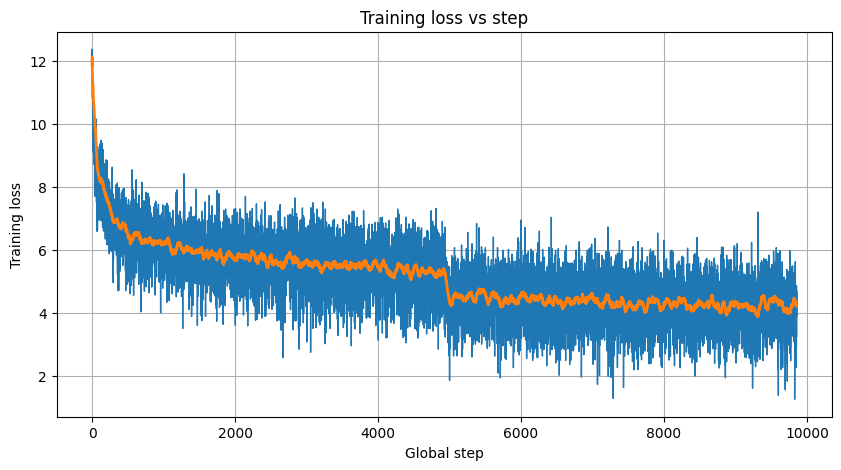

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df["step"], df["loss"], linewidth=1)

if SMOOTH_WINDOW and SMOOTH_WINDOW > 1 and len(df) >= SMOOTH_WINDOW:
    smooth = df["loss"].rolling(SMOOTH_WINDOW, min_periods=1).mean()
    plt.plot(df["step"], smooth, linewidth=2)

plt.xlabel("Global step")
plt.ylabel("Training loss")
plt.title("Training loss vs step")
plt.grid(True)
plt.show()


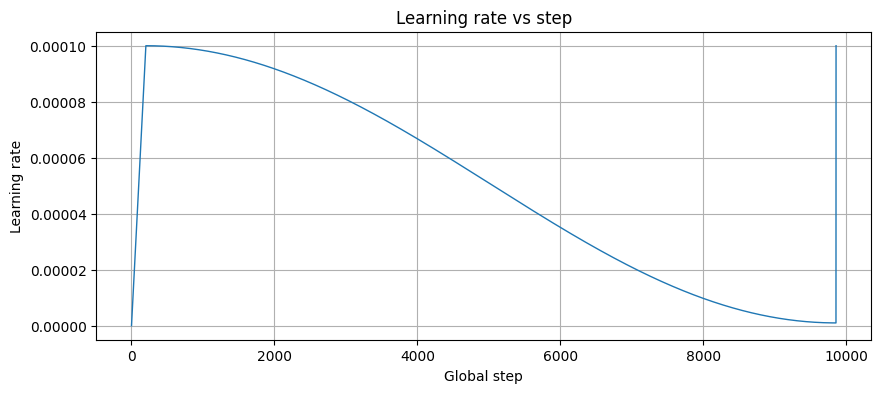

In [ ]:
LR_KEY = "optim/lr"
if LR_KEY in df_raw.columns:
    tmp = df_raw[[STEP_KEY, LR_KEY]].copy()
    tmp = tmp.rename(columns={STEP_KEY: "step", LR_KEY: "lr"})
    tmp["step"] = pd.to_numeric(tmp["step"], errors="coerce")
    tmp["lr"] = pd.to_numeric(tmp["lr"], errors="coerce")
    tmp = tmp.dropna().sort_values("step").drop_duplicates("step", keep="last")
    if DOWNSAMPLE_EVERY and DOWNSAMPLE_EVERY > 1:
        tmp = tmp.iloc[::DOWNSAMPLE_EVERY]

    plt.figure(figsize=(10, 4))
    plt.plot(tmp["step"], tmp["lr"], linewidth=1)
    plt.xlabel("Global step")
    plt.ylabel("Learning rate")
    plt.title("Learning rate vs step")
    plt.grid(True)
    plt.show()
else:
    print(f"{LR_KEY!r} not found in logs.")


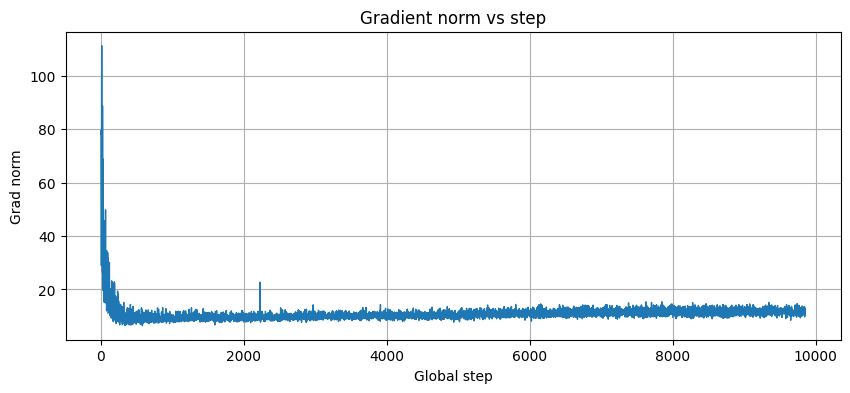

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df_raw["global_step"], df_raw["optim/grad_norm"], linewidth=1)
plt.xlabel("Global step")
plt.ylabel("Grad norm")
plt.title("Gradient norm vs step")
plt.grid(True)
plt.show()


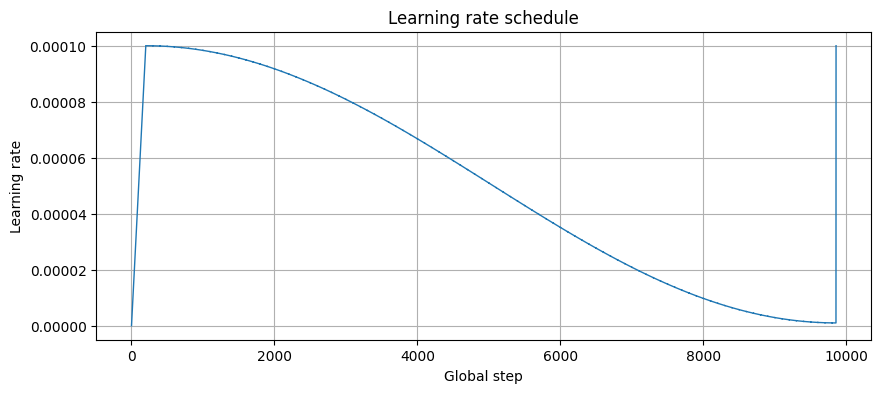

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df_raw["global_step"], df_raw["optim/lr"], linewidth=1)
plt.xlabel("Global step")
plt.ylabel("Learning rate")
plt.title("Learning rate schedule")
plt.grid(True)
plt.show()


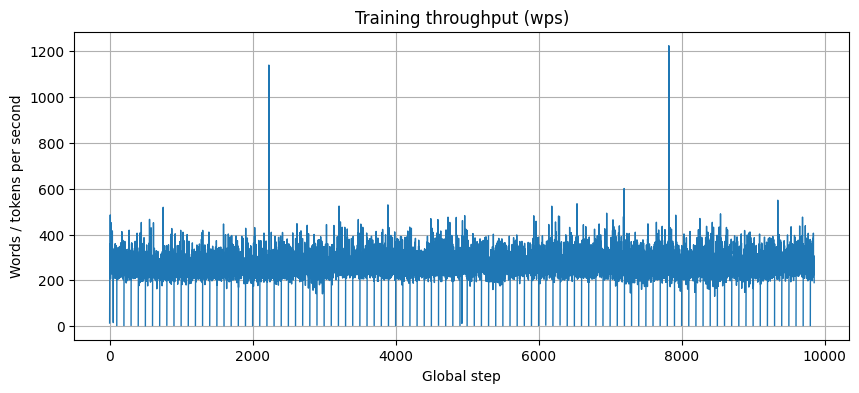

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df_raw["global_step"], df_raw["speed/wps"], linewidth=1)
plt.xlabel("Global step")
plt.ylabel("Words / tokens per second")
plt.title("Training throughput (wps)")
plt.grid(True)
plt.show()


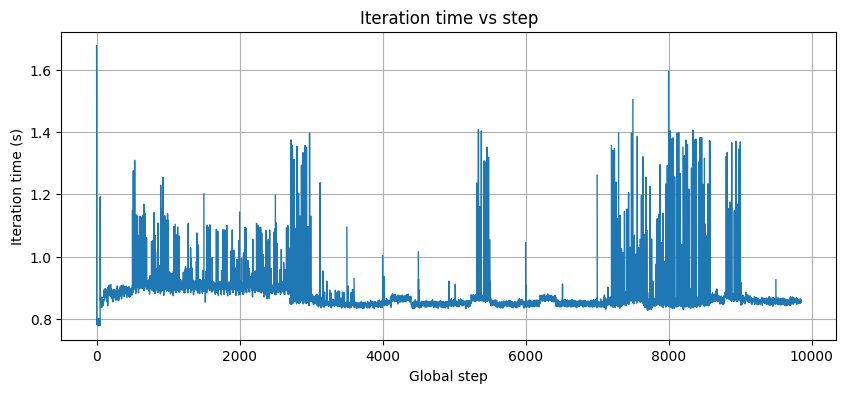

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df_raw["global_step"], df_raw["speed/curr_iter_time"], linewidth=1)
plt.xlabel("Global step")
plt.ylabel("Iteration time (s)")
plt.title("Iteration time vs step")
plt.grid(True)
plt.show()


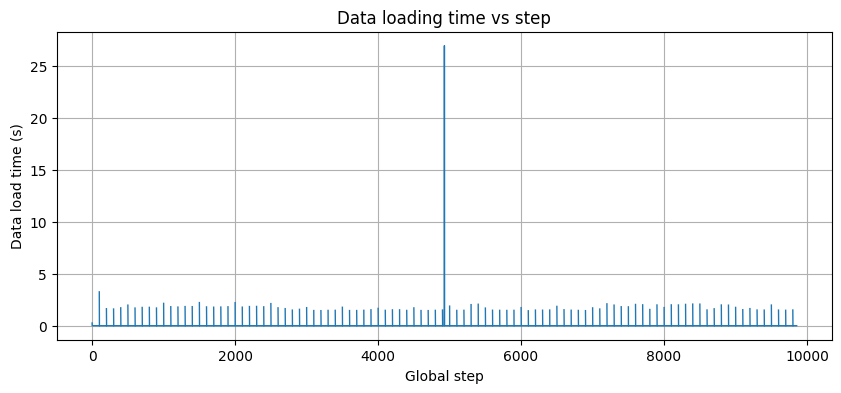

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df_raw["global_step"], df_raw["speed/data_load_time"], linewidth=1)
plt.xlabel("Global step")
plt.ylabel("Data load time (s)")
plt.title("Data loading time vs step")
plt.grid(True)
plt.show()


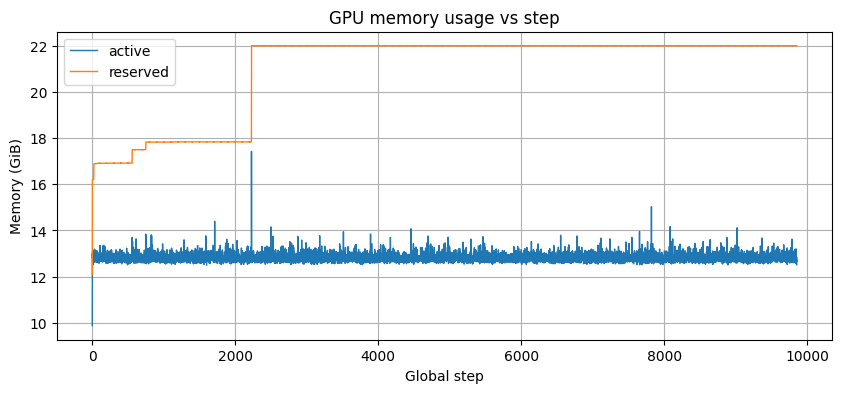

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df_raw["global_step"], df_raw["memory/max_active_gib"], label="active", linewidth=1)
plt.plot(df_raw["global_step"], df_raw["memory/max_reserved_gib"], label="reserved", linewidth=1)
plt.xlabel("Global step")
plt.ylabel("Memory (GiB)")
plt.title("GPU memory usage vs step")
plt.legend()
plt.grid(True)
plt.show()


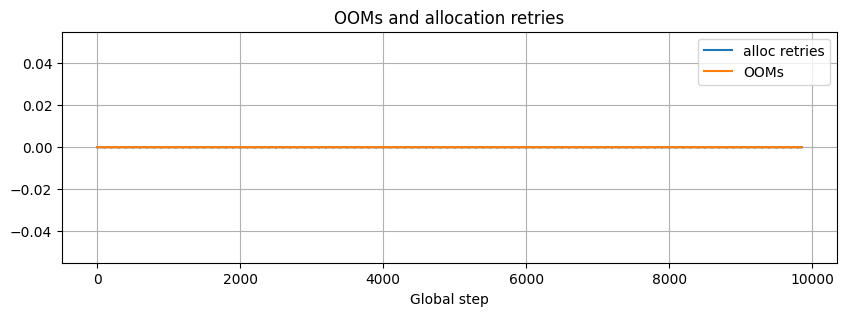

In [ ]:
plt.figure(figsize=(10, 3))
plt.plot(df_raw["global_step"], df_raw["memory/num_alloc_retries"], label="alloc retries")
plt.plot(df_raw["global_step"], df_raw["memory/num_ooms"], label="OOMs")
plt.xlabel("Global step")
plt.title("OOMs and allocation retries")
plt.legend()
plt.grid(True)
plt.show()


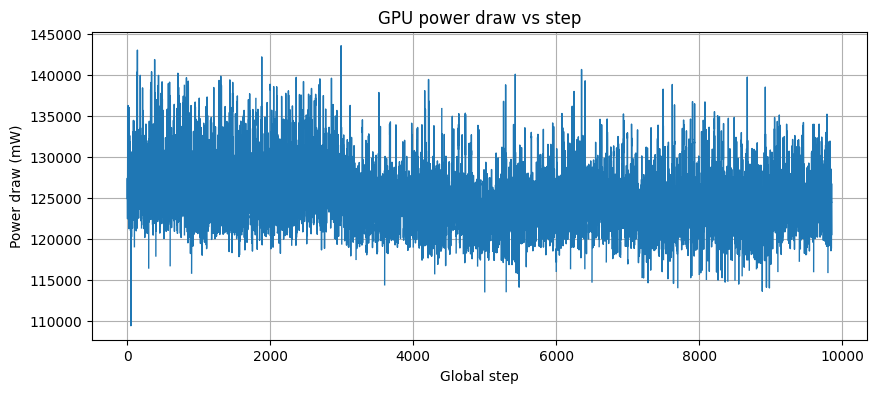

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df_raw["global_step"], df_raw["memory/power_draw"], linewidth=1)
plt.xlabel("Global step")
plt.ylabel("Power draw (mW)")
plt.title("GPU power draw vs step")
plt.grid(True)
plt.show()


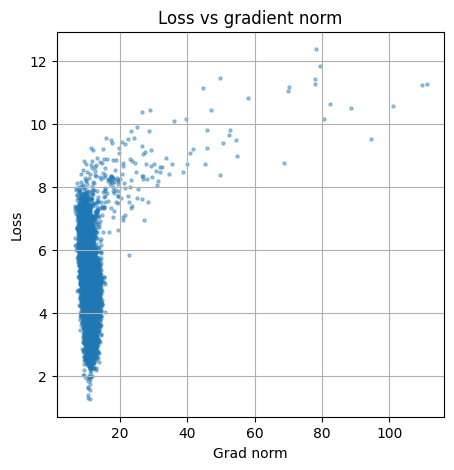

In [ ]:
plt.figure(figsize=(5, 5))
plt.scatter(df_raw["optim/grad_norm"], df_raw["loss/out"], s=5, alpha=0.4)
plt.xlabel("Grad norm")
plt.ylabel("Loss")
plt.title("Loss vs gradient norm")
plt.grid(True)
plt.show()

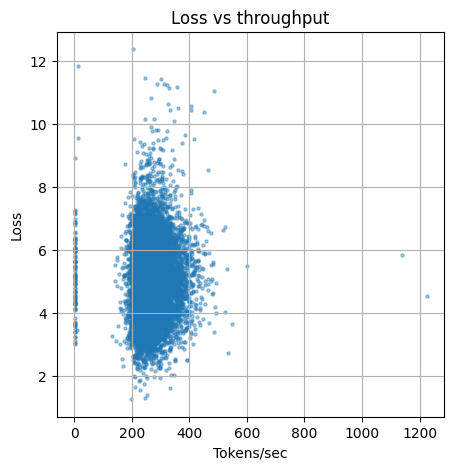

In [ ]:
plt.figure(figsize=(5, 5))
plt.scatter(df_raw["speed/wps"], df_raw["loss/out"], s=5, alpha=0.4)
plt.xlabel("Tokens/sec")
plt.ylabel("Loss")
plt.title("Loss vs throughput")
plt.grid(True)
plt.show()
